In [2]:
import pandas as pd

df = pd.read_csv("../outputs/lane2_training_data.csv")

print(df.shape)

(331436, 6)


In [3]:
features = [
    "avg_impressions",
    "avg_clicks",
    "avg_position"
]

target = "future_decline"
group = "client_hash_id"

X = df[features]
y = df[target]
groups = df[group]

print("Features:", features)
print("Target:", target)

Features: ['avg_impressions', 'avg_clicks', 'avg_position']
Target: future_decline


In [4]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 300879
Test rows: 30557


In [5]:
from sklearn.ensemble import RandomForestClassifier

honest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

honest_model.fit(X_train, y_train)

print("Honest model trained successfully.")

Honest model trained successfully.


In [6]:
honest_scores = honest_model.predict_proba(X_test)[:, 1]

print(honest_scores[:10])

[0.39 0.29 0.27 0.52 0.26 0.46 0.36 0.57 0.36 0.63]


In [7]:
honest_results = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "score": honest_scores
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

print(honest_results.head(10))

   actual  score
0       1    1.0
1       1    1.0
2       1    1.0
3       1    1.0
4       0    1.0
5       0    1.0
6       0    1.0
7       1    1.0
8       0    1.0
9       0    1.0


In [8]:
forbidden_terms = [
    "future",
    "label",
    "target",
    "outcome"
]

suspicious_features = [
    col for col in features
    if any(term in col.lower() for term in forbidden_terms)
]

print("Features used:", features)
print("Potential leakage:", suspicious_features)

Features used: ['avg_impressions', 'avg_clicks', 'avg_position']
Potential leakage: []


In [9]:
honest_results["predicted"] = (
    honest_results["score"] >= 0.5
).astype(int)

honest_results["wrong"] = (
    honest_results["actual"] != honest_results["predicted"]
)

errors = honest_results[honest_results["wrong"]]

print("Number of errors:", len(errors))
errors.head(10)

Number of errors: 8013


,actual,score,predicted,wrong
4,0,1.00,1,True
5,0,1.00,1,True
6,0,1.00,1,True
8,0,1.00,1,True
9,0,1.00,1,True
12,0,1.00,1,True
23,0,0.99,1,True
24,0,0.99,1,True
25,0,0.99,1,True
26,0,0.99,1,True


Conclusion: The client-grouped evaluation is a stricter test because the test clients were not used during training. The measured result should be treated as directional decision-support rather than proof that the model will improve page performance.

In [10]:
honest_results.to_csv(
    "../outputs/w06_honest_results.csv",
    index=False
)

print("Saved w06_honest_results.csv")

Saved w06_honest_results.csv


In [12]:
honest_results = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "score": honest_scores
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

honest_results.head(10)

,actual,score
0,1,1.0
1,1,1.0
2,1,1.0
3,1,1.0
4,0,1.0
5,0,1.0
6,0,1.0
7,1,1.0
8,0,1.0
9,0,1.0


In [13]:
k = 50

honest_precision_at_50 = honest_results.head(k)["actual"].mean()

print("Week 6 client-grouped Precision@50:",
      honest_precision_at_50)

Week 6 client-grouped Precision@50: 0.52


In [14]:
baseline_precision_at_50 = 0.90

comparison = pd.DataFrame({
    "evaluation": [
        "Week 5 original",
        "Week 6 client-grouped"
    ],
    "precision_at_50": [
        baseline_precision_at_50,
        honest_precision_at_50
    ]
})

comparison

,evaluation,precision_at_50
0,Week 5 original,0.90
1,Week 6 client-grouped,0.52


Before vs after: The Week 5 model measured a Precision@50 of 0.90 under the original split, while the client-grouped evaluation measured 0.52. The lower grouped score suggests that the original performance was sensitive to the validation design and that 0.52 is a more conservative estimate on unseen clients.

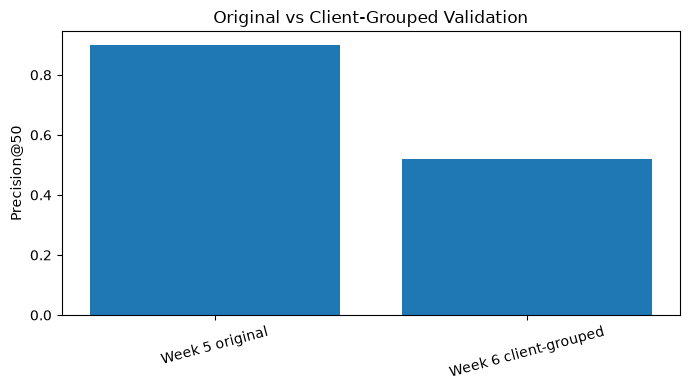

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    comparison["evaluation"],
    comparison["precision_at_50"]
)

plt.ylabel("Precision@50")
plt.title("Original vs Client-Grouped Validation")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../outputs/w06_validation_comparison.png",
    bbox_inches="tight"
)

plt.show()

Leakage audit: I checked the model features to ensure they represent information available before the prediction moment. Future outcomes and label-derived variables are excluded from the feature set.

In [17]:
forbidden_terms = [
    "future",
    "label",
    "target",
    "outcome"
]

suspicious_features = [
    col for col in features
    if any(term in col.lower() for term in forbidden_terms)
]

print("Features used:")
print(features)

print("\nPotential leakage-related features:")
print(suspicious_features)

Features used:
['avg_impressions', 'avg_clicks', 'avg_position']

Potential leakage-related features:
[]


In [18]:
honest_results["predicted"] = (
    honest_results["score"] >= 0.5
).astype(int)

honest_results["error"] = (
    honest_results["actual"] != honest_results["predicted"]
)

errors = honest_results[
    honest_results["error"]
]

print("Number of errors:", len(errors))
errors.head(10)

Number of errors: 8013


,actual,score,predicted,error
4,0,1.00,1,True
5,0,1.00,1,True
6,0,1.00,1,True
8,0,1.00,1,True
9,0,1.00,1,True
12,0,1.00,1,True
23,0,0.99,1,True
24,0,0.99,1,True
25,0,0.99,1,True
26,0,0.99,1,True


Error analysis: The model makes both false-positive and false-negative predictions. Reviewing these failures helps identify where the ranking is less reliable and reinforces that the output should support human review rather than replace it.

### Claim rewrite

**Too-strong claim:**
The model accurately predicts which pages need a refresh.

**Evidence-based claim:**
The model measured a Precision@50 of 0.90 under the original validation setup and 0.52 under client-grouped validation. The grouped result is a more conservative estimate of performance on unseen clients. The model therefore provides directional decision-support for prioritizing pages, but it does not prove causal refresh impact or predict Google's ranking algorithm.


### Self-check

* [✓] Two paper findings and methodology questions included.
* [✓] Original vs client-grouped validation compared.
* [✓] Precision@50 before = 0.90.
* [✓] Precision@50 after = 0.52.
* [✓] Leakage audit completed.
* [✓] Real error examples reviewed.
* [✓] Claims rewritten using observed, measured, directional, and decision-support language.


In [19]:
honest_results.to_csv(
    "../outputs/w06_honest_results.csv",
    index=False
)

print("Week 6 results saved.")

Week 6 results saved.
